In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)

(7043, 21)


In [4]:
df = df.drop("customerID", axis=1)

print(df.shape)

(7043, 20)


In [5]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [6]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 19)
Target: (7043,)


In [8]:
categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\AKANSHA\AppData\Local\Temp\ipykernel_11600\1821236580.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [9]:
print(categorical_columns)
print(numerical_columns)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [12]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (5634, 30)
Encoded testing shape: (1409, 30)


In [14]:
print(type(X_train_encoded))

<class 'numpy.ndarray'>


In [15]:
print("Training samples:", X_train_encoded.shape[0])
print("Testing samples:", X_test_encoded.shape[0])

Training samples: 5634
Testing samples: 1409


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [17]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_encoded, y_train)

C:\Users\AKANSHA\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
y_pred_logistic = logistic_model.predict(X_test_encoded)

y_prob_logistic = logistic_model.predict_proba(
    X_test_encoded
)[:, 1]

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))

Accuracy: 0.8048261178140526
Precision: 0.6561514195583596
Recall: 0.5561497326203209
F1 Score: 0.6020260492040521
ROC-AUC: 0.8426567464930635


In [20]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [21]:
cm = confusion_matrix(y_test, y_pred_logistic)

print(cm)

[[926 109]
 [166 208]]


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

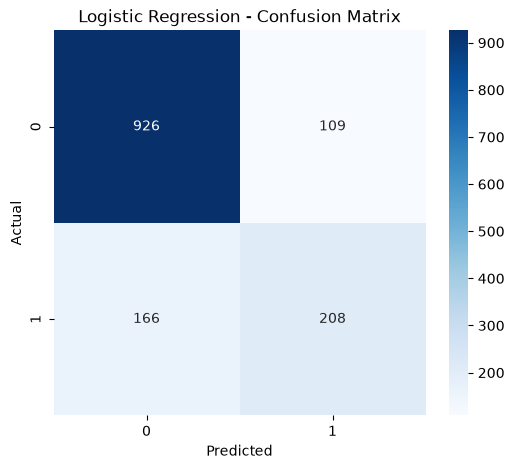

In [25]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))

Accuracy: 0.8048261178140526
Precision: 0.6561514195583596
Recall: 0.5561497326203209
F1 Score: 0.6020260492040521
ROC-AUC: 0.8426567464930635


In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [29]:
y_pred_rf = random_forest.predict(X_test_encoded)

y_prob_rf = random_forest.predict_proba(
    X_test_encoded
)[:, 1]

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7735982966643009
Precision: 0.5635103926096998
Recall: 0.6524064171122995
F1 Score: 0.6047087980173482
ROC-AUC: 0.8245098039215686


In [31]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.56      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.77      0.78      1409



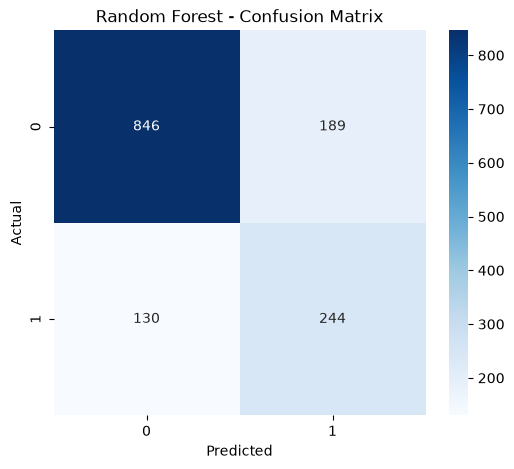

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8048,0.6562,0.5561,0.6020,0.8427
1,Random Forest,0.7736,0.5635,0.6524,0.6047,0.8245


In [34]:
import joblib

In [35]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression_churn.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [36]:
joblib.dump(
    preprocessor,
    "../models/churn_preprocessor.pkl"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [37]:
# Load original cleaned data so we can keep customer IDs
df_original = pd.read_csv(
    "../data/processed/telco_churn_cleaned.csv"
)

df_original.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
X_all = df_original.drop(
    ["customerID", "Churn"],
    axis=1
)

y_all = df_original["Churn"].map({
    "No": 0,
    "Yes": 1
})

X_all_encoded = preprocessor.transform(X_all)

In [39]:
all_predictions = logistic_model.predict(X_all_encoded)

all_probabilities = logistic_model.predict_proba(
    X_all_encoded
)[:, 1]

In [40]:
all_predictions = logistic_model.predict(X_all_encoded)

all_probabilities = logistic_model.predict_proba(
    X_all_encoded
)[:, 1]

In [41]:
prediction_df = pd.DataFrame({
    "customerID": df_original["customerID"],
    "Actual_Churn": y_all,
    "Churn_Probability": all_probabilities,
    "Predicted_Churn": all_predictions
})

prediction_df.head()

,customerID,Actual_Churn,Churn_Probability,Predicted_Churn
0,7590-VHVEG,0,0.616700,1
1,5575-GNVDE,0,0.046334,0
2,3668-QPYBK,1,0.296259,0
3,7795-CFOCW,0,0.029121,0
4,9237-HQITU,1,0.697169,1


In [42]:
def risk_category(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

prediction_df["Risk_Category"] = prediction_df[
    "Churn_Probability"
].apply(risk_category)

In [43]:
prediction_df["Risk_Category"].value_counts()

Risk_Category
Low Risk       4947
Medium Risk    1602
High Risk       494
Name: count, dtype: int64

In [44]:
prediction_df = prediction_df.merge(
    df_original[
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Contract",
            "InternetService",
            "PaymentMethod",
            "Churn"
        ]
    ],
    on="customerID",
    how="left"
)

In [45]:
    prediction_df.head()

,customerID,Actual_Churn,Churn_Probability,Predicted_Churn,Risk_Category,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,7590-VHVEG,0,0.616700,1,Medium Risk,1,29.85,29.85,Month-to-month,DSL,Electronic check,No
1,5575-GNVDE,0,0.046334,0,Low Risk,34,56.95,1889.50,One year,DSL,Mailed check,No
2,3668-QPYBK,1,0.296259,0,Low Risk,2,53.85,108.15,Month-to-month,DSL,Mailed check,Yes
3,7795-CFOCW,0,0.029121,0,Low Risk,45,42.30,1840.75,One year,DSL,Bank transfer (automatic),No
4,9237-HQITU,1,0.697169,1,Medium Risk,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,Yes


In [46]:
prediction_df.to_csv(
    "../outputs/churn_predictions.csv",
    index=False
)

print("Churn prediction output saved successfully.")

Churn prediction output saved successfully.


In [47]:
prediction_df.head()

,customerID,Actual_Churn,Churn_Probability,Predicted_Churn,Risk_Category,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,7590-VHVEG,0,0.616700,1,Medium Risk,1,29.85,29.85,Month-to-month,DSL,Electronic check,No
1,5575-GNVDE,0,0.046334,0,Low Risk,34,56.95,1889.50,One year,DSL,Mailed check,No
2,3668-QPYBK,1,0.296259,0,Low Risk,2,53.85,108.15,Month-to-month,DSL,Mailed check,Yes
3,7795-CFOCW,0,0.029121,0,Low Risk,45,42.30,1840.75,One year,DSL,Bank transfer (automatic),No
4,9237-HQITU,1,0.697169,1,Medium Risk,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,Yes


In [48]:
prediction_df["Risk_Category"].value_counts()

Risk_Category
Low Risk       4947
Medium Risk    1602
High Risk       494
Name: count, dtype: int64

In [49]:
prediction_df = prediction_df.drop(
    columns=["Actual_Churn"]
)

prediction_df.head()

,customerID,Churn_Probability,Predicted_Churn,Risk_Category,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,7590-VHVEG,0.616700,1,Medium Risk,1,29.85,29.85,Month-to-month,DSL,Electronic check,No
1,5575-GNVDE,0.046334,0,Low Risk,34,56.95,1889.50,One year,DSL,Mailed check,No
2,3668-QPYBK,0.296259,0,Low Risk,2,53.85,108.15,Month-to-month,DSL,Mailed check,Yes
3,7795-CFOCW,0.029121,0,Low Risk,45,42.30,1840.75,One year,DSL,Bank transfer (automatic),No
4,9237-HQITU,0.697169,1,Medium Risk,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,Yes


In [50]:
print(prediction_df.shape)
print(prediction_df.columns.tolist())

(7043, 11)
['customerID', 'Churn_Probability', 'Predicted_Churn', 'Risk_Category', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'PaymentMethod', 'Churn']


In [51]:
prediction_df.to_csv(
    "../outputs/churn_predictions.csv",
    index=False
)

print("Prediction dataset saved successfully.")

Prediction dataset saved successfully.
